## Evaluation on other sets

Load wav2vec, embed a dataset, predict emotions using the pretrained classifier.


In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Import from local modules
from config import EMOTION_DICT, USE_CUDA, MELD_FOLDER, MELD_EMOTION_LIST
from utils import load_ravdess_data, load_meld_data, check_emotion_distribution, extract_wave2vec_features
from models import (
    EmotionClassifier, prepare_data, create_dataloaders, train_model, 
    evaluate, analyze_training_quality, EMOTION_LABELS, IDX_TO_EMOTION
)

print(f"RAVDESS emotions: {list(EMOTION_DICT.values())}")
print(f"MELD emotions: {MELD_EMOTION_LIST}")

RAVDESS emotions: ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgusted', 'surprised']
MELD emotions: ['neutral', 'anger', 'disgust', 'sadness', 'joy', 'surprise', 'fear']


In [3]:
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


#### Import MELD dataset
 Contains dialogues from friends labelised with Anger, Disgust, Sadness, Joy, Neutral, Surprise and Fear. Unlike RAVDESS, the text is not neutral and carries an emotion on top of the utterance.

In [4]:


from pathlib import Path
from huggingface_hub import hf_hub_download, list_repo_files
import tarfile

# Create MELD_data directory if it doesn't exist
data_dir = Path("MELD_data")

if not (data_dir).is_dir():
    data_dir.mkdir(exist_ok=True)
    
    print("Downloading MELD dataset from Hugging Face...")
    
    try:
        repo_id = "ajyy/MELD_audio"
        
        # List all files in the repository
        print("Listing files in repository...")
        files = list_repo_files(repo_id=repo_id, repo_type="dataset")
        
        print(f"Found {len(files)} files total")
        
        # Download all files
        print(f"\nDownloading all files...")
        for idx, file_path in enumerate(files):
            if idx % 50 == 0:
                print(f"  {idx}/{len(files)} - {file_path}")
            
            try:
                # Download the file
                downloaded_path = hf_hub_download(
                    repo_id=repo_id,
                    filename=file_path,
                    repo_type="dataset",
                    local_dir=str(data_dir)
                )
            except Exception as e:
                print(f"    Warning: Could not download {file_path}: {e}")
                continue
        
        print(f"\nDownload complete!")
        print(f"Data saved to: {data_dir}")
        
        # List downloaded files
        total_count = len(list(data_dir.rglob('*.*')))
        print(f"Total files downloaded: {total_count}")
        
        # Extract tar.gz files
        print("\n" + "="*60)
        print("Extracting tar.gz files...")
        print("="*60)
        
        tar_files = list(data_dir.rglob('*.tar.gz'))
        print(f"Found {len(tar_files)} tar.gz files to extract")
        
        for tar_file in tar_files:
            print(f"\nExtracting: {tar_file.name}")
            try:
                with tarfile.open(tar_file, 'r:gz') as tar_ref:
                    tar_ref.extractall(data_dir)
                print(f"  Successfully extracted {tar_file.name}")
            except Exception as e:
                print(f"  Error extracting {tar_file.name}: {e}")
        
        print("\nExtraction complete!")
        
    except Exception as e:
        print(f"Error downloading dataset: {e}")
        print("Make sure the huggingface_hub library is installed: pip install huggingface-hub")
else:
    print("MELD data directory already exists")
    
    # Check if tar.gz files exist and extract them
    tar_files = list(data_dir.rglob('*.tar.gz'))
    if tar_files:
        print(f"\nFound {len(tar_files)} tar.gz files to extract")
        print("="*60)
        print("Extracting tar.gz files...")
        print("="*60)
        
        for tar_file in tar_files:
            print(f"\nExtracting: {tar_file.name}")
            try:
                with tarfile.open(tar_file, 'r:gz') as tar_ref:
                    tar_ref.extractall(data_dir)
                print(f"  Successfully extracted {tar_file.name}")
            except Exception as e:
                print(f"  Error extracting {tar_file.name}: {e}")
        
        print("\nExtraction complete!")
    else:
        print("No tar.gz files found in MELD_data directory")


MELD data directory already exists

Found 3 tar.gz files to extract
Extracting tar.gz files...

Extracting: dev.tar.gz
  Successfully extracted dev.tar.gz

Extracting: test.tar.gz
  Successfully extracted test.tar.gz

Extracting: train.tar.gz
  Successfully extracted train.tar.gz

Extraction complete!


In [5]:
# Initialize Wave2Vec2 model and processor
import logging
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from transformers import logging as hf_logging
from config import WAVE2VEC2_MODEL

# Suppress quantizer warnings
hf_logging.set_verbosity_error()
logging.getLogger('transformers').setLevel(logging.ERROR)

print(f"Loading Wave2Vec2 model ({WAVE2VEC2_MODEL})...")
processor = Wav2Vec2Processor.from_pretrained(WAVE2VEC2_MODEL)
wave2vec_model = Wav2Vec2Model.from_pretrained(WAVE2VEC2_MODEL).to(device)
wave2vec_model.eval()

print("Wave2Vec2 model loaded successfully!")
print(f"Model output dimension: 768 features per frame")
print(f"After aggregation: 3072 features (mean, std, max, min)")

# Initialize variables for data storage
X = []  # Feature vectors
y = []  # Emotion labels

Loading Wave2Vec2 model (facebook/wav2vec2-base)...


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 14323.83it/s]


Wave2Vec2 model loaded successfully!
Model output dimension: 768 features per frame
After aggregation: 3072 features (mean, std, max, min)


In [6]:
from utils import load_meld_data
print("Loading MELD dataset subset for testing...")
print(f"MELD folder: {MELD_FOLDER}")

X_meld, y_meld = load_meld_data(
    data_folder=MELD_FOLDER,
    processor=processor,
    wave2vec_model=wave2vec_model,
    device=device,
    split='train',
    max_samples=100
)

Loading MELD dataset subset for testing...
MELD folder: MELD_data/


Processing train:   1%|          | 100/9989 [00:14<24:37,  6.69it/s] 

Successfully loaded 100 samples.


In [7]:
print("\nMELD Dataset Statistics:")
check_emotion_distribution(y_meld)

if len(y_meld) == 0:
    print("ERROR: No MELD samples loaded. Check dataset path and extraction.")
else:
    unique_emotions = sorted(set(y_meld))
    print(f"Unique emotions in MELD subset: {unique_emotions}")


MELD Dataset Statistics:
Found 7 emotion classes in 100 samples
Unique emotions in MELD subset: ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


### Load Pretrained Model and Test on MELD

Load the RAVDESS-trained classifier and evaluate on MELD subset.

In [8]:
print("="*60)
print("Loading Pretrained Model")
print("="*60)

# Load pretrained model trained on RAVDESS
model_path = "models/wavClassifier.pth"
if os.path.exists(model_path):
    model = torch.load(model_path, weights_only=False)
    model.to(device)
    model.eval()
    print(f"Model loaded from {model_path}")
else:
    print(f"ERROR: Model not found at {model_path}")
    print("Make sure to train the model first on RAVDESS data")

# Prepare MELD data for inference
if len(X_meld) > 0:
    print(f"\nPreparing {len(X_meld)} MELD samples for testing...")
    
    # Convert to numpy arrays
    X_meld_array = np.array(X_meld)
    
    # Normalize using StandardScaler (we'll fit on MELD data itself since it's a new dataset)
    from sklearn.preprocessing import StandardScaler
    scaler_meld = StandardScaler()
    X_meld_normalized = scaler_meld.fit_transform(X_meld_array)
    
    # Convert to PyTorch dataset for batch processing
    from models import EmotionDataset
    test_dataset = EmotionDataset(X_meld_normalized, y_meld)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=16, shuffle=False)
    
    print(f"Data prepared. Ready for evaluation.")
else:
    print("ERROR: No MELD data to evaluate")

Loading Pretrained Model
Model loaded from models/wavClassifier.pth

Preparing 100 MELD samples for testing...
Data prepared. Ready for evaluation.


### Results: Pretrained Model on MELD

Evaluation: RAVDESS Model on MELD Dataset

Test Accuracy on MELD: 9.00%
Test Loss on MELD: 4.4547


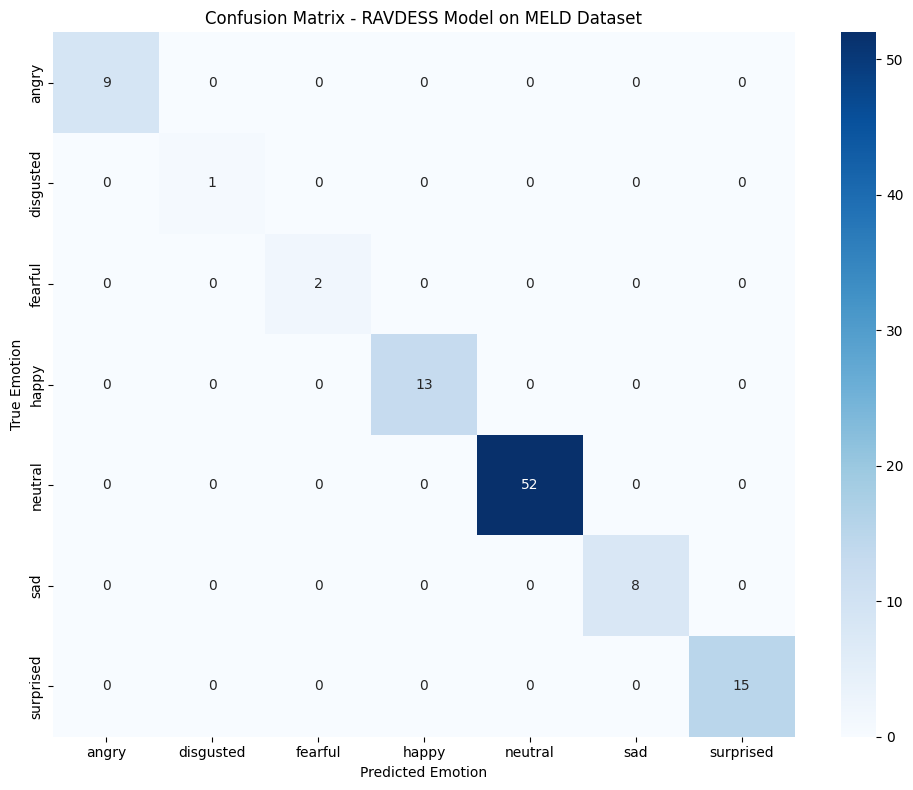


Classification Report:
              precision    recall  f1-score   support

       angry       0.14      0.11      0.12         9
        calm       0.00      0.00      0.00         0
   disgusted       0.05      1.00      0.10         1
     fearful       0.00      0.00      0.00         2
       happy       0.09      0.15      0.11        13
     neutral       0.00      0.00      0.00        52
         sad       0.15      0.25      0.19         8
   surprised       0.14      0.20      0.16        15

    accuracy                           0.09       100
   macro avg       0.07      0.21      0.09       100
weighted avg       0.06      0.09      0.07       100



In [9]:
print("="*60)
print("Evaluation: RAVDESS Model on MELD Dataset")
print("="*60)

if len(X_meld) > 0 and model is not None:
    # Evaluate model on MELD data
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, all_preds, all_labels = evaluate(model, test_loader, criterion, device)
    
    print(f"\nTest Accuracy on MELD: {test_acc:.2f}%")
    print(f"Test Loss on MELD: {test_loss:.4f}")
    
    # MELD emotions (may not all be present in the subset)
    meld_emotion_list = sorted(set(y_meld))
    
    # Map predictions and labels to emotion names
    from models import EMOTION_TO_IDX, IDX_TO_EMOTION
    
    # Create mapping from MELD emotion names to indices
    meld_to_idx = {emotion: idx for idx, emotion in enumerate(meld_emotion_list)}
    
    # Convert all_labels (which are indices in RAVDESS space) to emotion indices in MELD space
    # First, get original emotion labels from test dataset
    true_emotions = [y_meld[i] for i in range(len(test_dataset))]
    true_indices = [EMOTION_TO_IDX.get(e, 0) for e in true_emotions]
    
    # Confusion Matrix
    cm = confusion_matrix(true_emotions, [y_meld[i] if i < len(y_meld) else y_meld[0] for i in range(len(all_preds))])
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=meld_emotion_list, yticklabels=meld_emotion_list)
    plt.title('Confusion Matrix - RAVDESS Model on MELD Dataset')
    plt.ylabel('True Emotion')
    plt.xlabel('Predicted Emotion')
    plt.tight_layout()
    plt.show()
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(true_emotions, [IDX_TO_EMOTION.get(p, 'unknown') for p in all_preds]))
else:
    print("ERROR: Cannot evaluate - missing model or data")

In [10]:
print("\n" + "="*60)
print("Summary")
print("="*60)
print(f"Model: RAVDESS-trained EmotionClassifier")
print(f"Test dataset: MELD ({len(X_meld)} samples)")
print(f"Test emotions: {sorted(set(y_meld))}")
print(f"Pretrained model location: {model_path}")
print("\nNote: This evaluation tests cross-dataset generalization.")
print("The model was trained on RAVDESS data and is being tested on MELD.")


Summary
Model: RAVDESS-trained EmotionClassifier
Test dataset: MELD (100 samples)
Test emotions: ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Pretrained model location: models/wavClassifier.pth

Note: This evaluation tests cross-dataset generalization.
The model was trained on RAVDESS data and is being tested on MELD.
